# Bibliotecas 📚

In [ ]:
# Bibliotecas do PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets as ds
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
# Bibliotecas de visualização de imagens
import PIL
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
from torchvision.transforms import ToPILImage
# Bibliotecas de importação de modelos
import transformers
from transformers import pipeline
import kagglehub
from transformers import AutoImageProcessor, AutoModelForImageClassification
# Bibliotecas gerais
from google.colab import files
import time

# Tensores 🧱
[Documentação](https://pytorch.org/docs/stable/generated/torch.tensor.html#torch.tensor)

In [ ]:
# Generate the tensor of all zeros
x = torch.zeros(3,3)
print(x)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [ ]:
# Generate the tensor of all ones
x = torch.ones(3,3)
print(x)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])


In [ ]:
# Generate the tensor of all random values
x = torch.rand(3,3)
print(x)

tensor([[0.0455, 0.1042, 0.9421],
        [0.0930, 0.2965, 0.6764],
        [0.4971, 0.9819, 0.3432]])


In [ ]:
x = torch.full((3,3),1)
print(x)

tensor([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]])


# Crição do modelo de Rede Neural 🧠
[Documentação](https://pytorch.org/docs/stable/nn.html#)

In [ ]:
class modelo(nn.Module):
    def __init__(self):
        super(modelo, self).__init__()
        self.flatten = nn.Flatten()
        self.primeira_camada = nn.Linear(in_features=784,out_features=64)
        self.segunda_camada = nn.Linear(in_features=64,out_features=10)
        self.relu = nn.ReLU()

    def forward(self, x):
      x = self.flatten(x)
      x = self.primeira_camada(x)
      x = self.relu(x)
      x = self.segunda_camada(x)
      return x
modelo1 = modelo()

In [ ]:
modelo_seq = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784,out_features=64),
    nn.ReLU(),
    nn.Linear(in_features=64,out_features=10)
)
print(modelo_seq)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=64, bias=True)
  (2): ReLU()
  (3): Linear(in_features=64, out_features=10, bias=True)
)


In [ ]:
# modelo_hf = pipeline("image-classification", model="corralesvr/my_test_numbers_model")
processor = AutoImageProcessor.from_pretrained("corralesvr/my_test_numbers_model")
modelo_hf = AutoModelForImageClassification.from_pretrained("corralesvr/my_test_numbers_model")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

# Datasets e Dataloaders 📊

## Huggingface 🤗

In [ ]:
from huggingface_hub import login
login()

In [ ]:
!pip install datasets
from datasets import load_dataset


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system ==

In [ ]:
dataset_hf = load_dataset("ylecun/mnist")
dataset_hf_train = dataset_hf["train"].with_format("torch")
dataset_hf_test = dataset_hf["test"].with_format("torch")

dataloader_hf_train = DataLoader(dataset_hf_train, batch_size=64, shuffle=True)
dataloader_hf_test = DataLoader(dataset_hf_test, batch_size=1, shuffle=False)


README.md:   0%|          | 0.00/6.97k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
display(dataset_hf["train"][0]["image"])
print(dataset_hf)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})


## Kaggle 🇰

In [ ]:
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")
dataset_kaggle_train = path + "/mnist_train.csv"

## Pytorch 🔥

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0, 1]
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize for MNIST
])
train_dataset = ds.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = ds.MNIST(root="./data", train=False, download=True, transform=transform)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=10000, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.46MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.30MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.35MB/s]


In [ ]:
print(train_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )


# Treinamento 🏋️‍♂️

In [ ]:
epochs = 10
lr = 0.001

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(modelo1.parameters(), lr=lr, momentum=0.9)

In [ ]:
def train(model, optimizer, loss_fn, dataloader):
    loss_list = []
    # 1. Define the training loop
    for epoch in range(epochs):
        epoch_loss = 0
        for images, labels in dataloader:

            # image.to(device)
            # labels.to(device)

            optimizer.zero_grad()

            output = model(images)

            loss = loss_fn(output, labels)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(dataloader)
        loss_list.append(avg_epoch_loss)
        print(f"[Epoch: {epoch+1}, Loss: {avg_epoch_loss:.3f}]")

    print("Done Training!!!")
    return loss_list

In [ ]:
modelo1.train()
losses = train(modelo1, optimizer, loss_fn, train_dataloader)

[Epoch: 1, Loss: 0.621]
[Epoch: 2, Loss: 0.308]
[Epoch: 3, Loss: 0.265]
[Epoch: 4, Loss: 0.236]
[Epoch: 5, Loss: 0.213]
[Epoch: 6, Loss: 0.195]
[Epoch: 7, Loss: 0.179]
[Epoch: 8, Loss: 0.166]
[Epoch: 9, Loss: 0.154]
[Epoch: 10, Loss: 0.145]
Done Training!!!


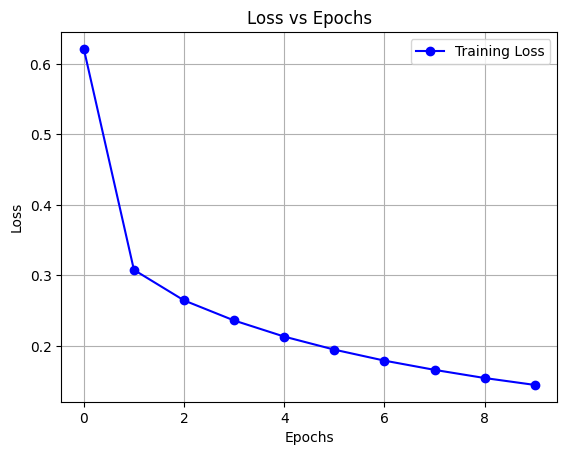

In [ ]:
plt.plot(losses, label='Training Loss', color='b', marker='o')

plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# Testing ✅

In [ ]:
def test(model, dataloader, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0

    with torch.no_grad():
        for images, labels in dataloader:

            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / len(dataloader.dataset)
    print(f"Test Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    return avg_loss, accuracy


In [ ]:
def test_hf(model, dataloader, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0

    for images, labels in dataloader:
        inputs = processor(images=images, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)
            correct += (predictions == labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / len(dataloader.dataset)
    print(f"Test Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

In [ ]:
test(modelo1, test_dataloader, loss_fn)

Test Loss: 0.1444 | Test Accuracy: 95.81%


(0.14436624944210052, 95.81)

In [ ]:
# test_hf(modelo_hf, dataloader_hf_test, loss_fn)

ValueError: Invalid image type. Expected either PIL.Image.Image, numpy.ndarray, torch.Tensor, tf.Tensor or jax.ndarray, but got <class 'str'>.

In [ ]:
modelo1.eval()
for(image,label) in test_dataset:
    output = modelo1(image)
    prediction = torch.argmax(output)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}\nPrediction: {prediction}")
    plt.axis("off")
    plt.show()
    time.sleep(1)